In [4]:
import pandas as pd

#====================================
#Load Data
data=pd.read_csv('/content/DailyDelhiClimateTrain.csv', index_col='date' )
data.info()
data.head(5)


<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1+ KB


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
data.describe()
data.dtypes

,0
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


In [6]:
df=data.copy()
df.isna().sum()

,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [7]:
df.columns
df['meantemp']

,meantemp
date,
2013-01-01,10.000000
2013-01-02,7.400000
2013-01-03,7.166667
2013-01-04,8.666667
2013-01-05,6.000000
...,...
2016-12-28,17.217391
2016-12-29,15.238095
2016-12-30,14.095238


In [8]:
from numpy import datetime64
df.index
print(df.index.is_monotonic_increasing)
print(df.index.duplicated().sum())
print(df.index.dtype)

#convert index into datetime
df.index=pd.to_datetime(df.index)

True
0
object


In [9]:
print(df.index.dtype)


datetime64[ns]


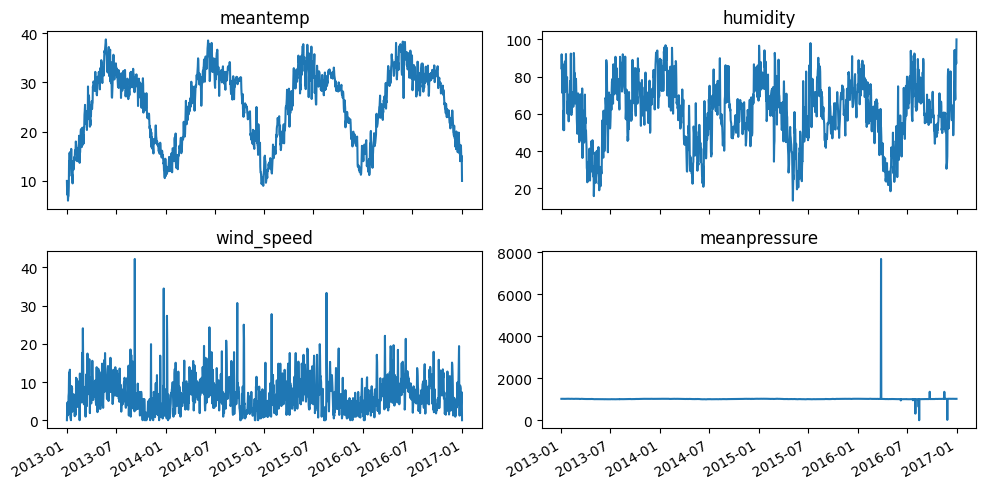

In [10]:
from matplotlib import figure
#Visualinging columns
import matplotlib.pyplot as plt

fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(10,5))
ax=ax.flatten()

for i,col in enumerate(df.columns):
  ax[i].plot(df.index,df[col])
  ax[i].set_title(col)

fig.autofmt_xdate() #to rotate labels
plt.tight_layout()
plt.show()

#meantemp shows strong yearly seasonality


count    1462.000000
mean     1011.104548
std       180.231668
min        -3.041667
25%      1001.580357
50%      1008.563492
75%      1014.944901
max      7679.333333
Name: meanpressure, dtype: float64


<Axes: >

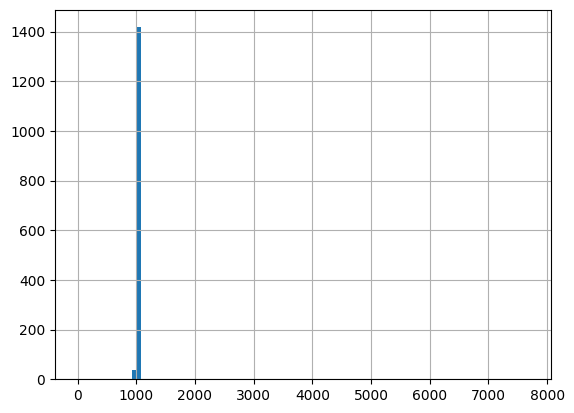

In [11]:
print(df['meanpressure'].describe())
#print(df['meanpressure'].sort_values().head(20))
#print(df['meanpressure'].sort_values().tail(20))
df['meanpressure'].hist(bins=100)

meantemp        0
humidity        0
wind_speed      0
meanpressure    9
dtype: int64
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


<Axes: >

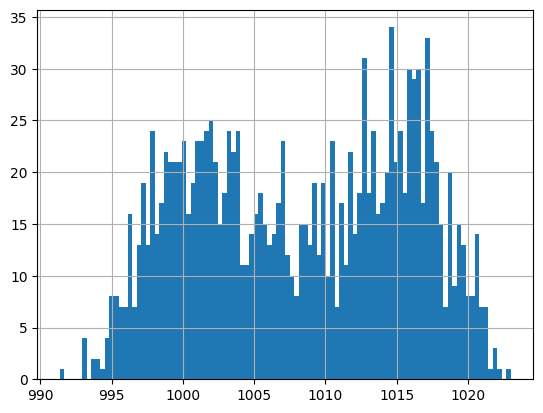

In [12]:
#Convert impossible values to NaN
import numpy as np

q1=df['meanpressure'].quantile(0.25)
q3=df['meanpressure'].quantile(0.75)

#Data points that fall below Q1−1.5×IQR or above Q3+1.5×IQR are considered outliers
IQR=q3 - q1
lower=q1 - 1.5 * IQR
upper=q3 + 1.5 * IQR

df.loc[ (df['meanpressure']< lower) | (df['meanpressure']>upper)]

df.loc[ (df['meanpressure']< lower) | (df['meanpressure']>upper),"meanpressure"]=np.nan
print(df.isnull().sum())

#interpolate
df["meanpressure"]=df["meanpressure"].interpolate(method="time")
print(df.isnull().sum())
df['meanpressure'].hist(bins=100)

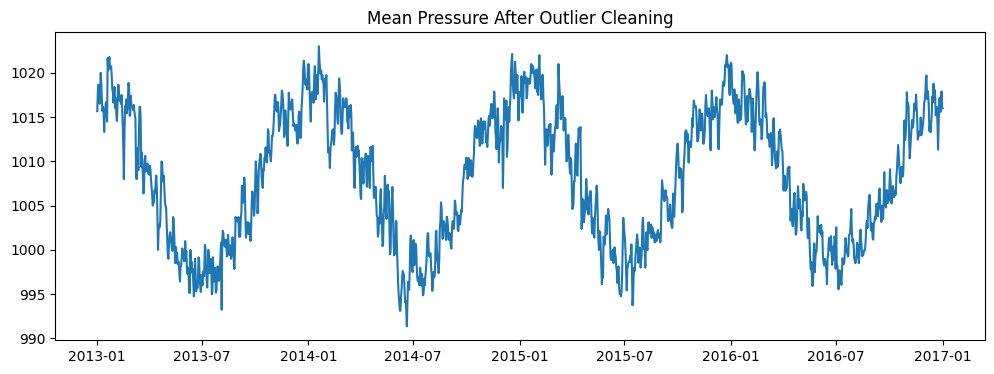

In [13]:
plt.figure(figsize=(12,4))
plt.plot(df.index,df["meanpressure"])
plt.title("Mean Pressure After Outlier Cleaning")
plt.show()

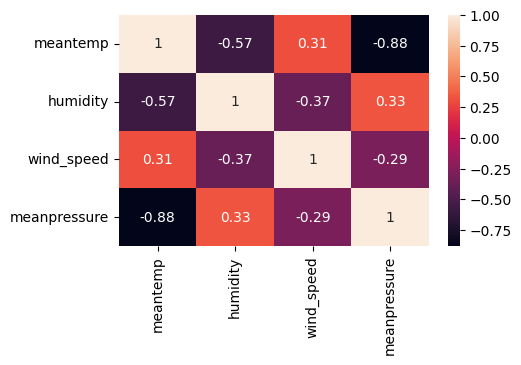

In [15]:
import seaborn as sns
plt.figure(figsize=(5,3))
sns.heatmap(df.corr(),annot=True)
plt.show()

#captures only linear relation
#absolute value od relation is considered
#therefore highest correlattion is 0.88 between target and meanpressure

In [17]:
#Temperature lags
target=df["meantemp"]

df['lag_1']=target.shift(1)
df['lag_7']=target.shift(7)
df['lag_14']=target.shift(14)
df['lag_30']=target.shift(30)

#Temperature rolling statistics
df['rolling_mean_7']=target.rolling(7).mean()
df['rolling_mean_30']=target.rolling(30).mean()
df['rolling_std_7']=target.rolling(7).std()

#calender features
df['day_of_week']=df.index.day_of_week
df['day_of_year']=df.index.day_of_year
df['month']=df.index.month

print(df.columns)

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'lag_1', 'lag_7',
       'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30',
       'rolling_std_7', 'day_of_week', 'day_of_year', 'month'],
      dtype='object')


In [19]:
print(df.isnull().sum())

#drop nans created by new features
df=df.dropna()
print(df.isnull().sum())

meantemp            0
humidity            0
wind_speed          0
meanpressure        0
lag_1               1
lag_7               7
lag_14             14
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
rolling_std_7       6
day_of_week         0
day_of_year         0
month               0
dtype: int64
meantemp           0
humidity           0
wind_speed         0
meanpressure       0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
day_of_week        0
day_of_year        0
month              0
dtype: int64


In [22]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

xgb_reg=XGBRegressor(

    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42

)

tscv=TimeSeriesSplit(gap=0,n_splits=5)

mae_scores=[]
rmse_scores=[]
r2_scores=[]

X=df.drop(columns=['meantemp'])
y=target

for i,(train_index,test_index) in enumerate(tscv.split(X)):

  x_train=X.iloc[train_index]
  y_train=y.iloc[train_index]

  x_test=X.iloc[test_index]
  y_test=y.iloc[test_index]

  xgb_model=xgb_reg.fit(x_train,y_train)
  y_pred=xgb_model.predict(x_test)

  mae=mean_absolute_error(y_test,y_pred)
  rmse=root_mean_squared_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)

  mae_scores.append(mae)
  rmse_scores.append(rmse)
  r2_scores.append(r2)

  print(f"Fold {i+1}")
  print("MAE:", mae)
  print("RMSE:", rmse)
  print("R2:", r2)
  print("-"*30)

print("\nAverage Results")
print("MAE :", np.mean(mae_scores))
print("RMSE:", np.mean(rmse_scores))
print("R2  :", np.mean(r2_scores))

Fold 1
MAE: 0.1582419908347249
RMSE: 0.24981140570491125
R2: 0.9983432112499034
------------------------------
Fold 2
MAE: 0.08657276862274614
RMSE: 0.13709832908132083
R2: 0.9994312850964007
------------------------------
Fold 3
MAE: 0.07874418535724838
RMSE: 0.12893407422179795
R2: 0.9997490893141262
------------------------------
Fold 4
MAE: 0.047748651064636764
RMSE: 0.062659785112391
R2: 0.9999042227110125
------------------------------
Fold 5
MAE: 0.0844930893730855
RMSE: 0.10729422185393869
R2: 0.9993354034950037
------------------------------

Average Results
MAE : 0.09116013705048834
RMSE: 0.13715956319487194
R2  : 0.9993526423732894


In [28]:
#how yesterday's info relates to today's values.
df['humidity_lag_1']=df['humidity'].shift(1)
df['wind_speed_lag_1']=df['wind_speed'].shift(1)
df['meanpressure_lag_1']=df['meanpressure'].shift(1)
print(df.columns)

print(df.isnull().sum())
df=df.dropna()

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'lag_1', 'lag_7',
       'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30',
       'rolling_std_7', 'day_of_week', 'day_of_year', 'month',
       'humidity_lag_1', 'wind_speed_lag_1', 'meanpressure_lag_1'],
      dtype='object')
meantemp              0
humidity              0
wind_speed            0
meanpressure          0
lag_1                 0
lag_7                 0
lag_14                0
lag_30                0
rolling_mean_7        0
rolling_mean_30       0
rolling_std_7         0
day_of_week           0
day_of_year           0
month                 0
humidity_lag_1        1
wind_speed_lag_1      1
meanpressure_lag_1    1
dtype: int64


In [29]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


mae_scores=[]
rmse_scores=[]
r2_scores=[]

X=df.drop(columns=['meantemp','humidity','wind_speed','meanpressure'])
y=target

for i,(train_index,test_index) in enumerate(tscv.split(X)):

  x_train=X.iloc[train_index]
  y_train=y.iloc[train_index]

  x_test=X.iloc[test_index]
  y_test=y.iloc[test_index]

  xgb_model=xgb_reg.fit(x_train,y_train)
  y_pred=xgb_model.predict(x_test)

  mae=mean_absolute_error(y_test,y_pred)
  rmse=root_mean_squared_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)

  mae_scores.append(mae)
  rmse_scores.append(rmse)
  r2_scores.append(r2)

  print(f"Fold {i+1}")
  print("MAE:", mae)
  print("RMSE:", rmse)
  print("R2:", r2)
  print("-"*30)

print("\nAverage Results")
print("MAE :", np.mean(mae_scores))
print("RMSE:", np.mean(rmse_scores))
print("R2  :", np.mean(r2_scores))

Fold 1
MAE: 2.2995136646424923
RMSE: 2.879672270389116
R2: 0.7791997664317251
------------------------------
Fold 2
MAE: 1.3548889037213983
RMSE: 1.7538306940535244
R2: 0.9035019942523865
------------------------------
Fold 3
MAE: 1.3744864183313705
RMSE: 1.807034446537605
R2: 0.9511355776482043
------------------------------
Fold 4
MAE: 1.0015103281210953
RMSE: 1.2788231775465542
R2: 0.9602011218334074
------------------------------
Fold 5
MAE: 1.2764919105308172
RMSE: 1.640373184638662
R2: 0.8394643553948026
------------------------------

Average Results
MAE : 1.4613782450694346
RMSE: 1.8719467546330926
R2  : 0.8867005631121051
